In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:
df=pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.shape

(20640, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [7]:
import seaborn as sns



In [10]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [12]:
df.dropna(inplace=True)

In [13]:
df.duplicated().sum()

np.int64(0)

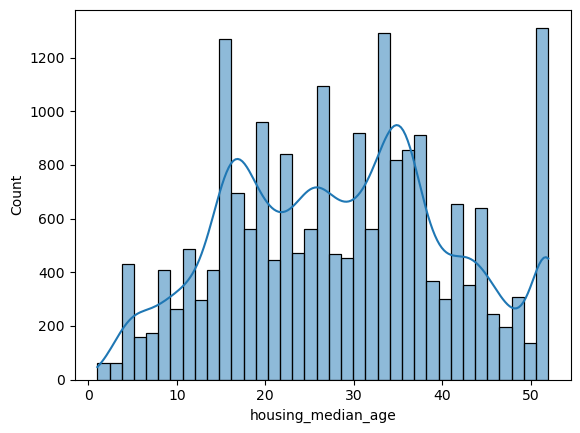

In [14]:
sns.histplot(x=df["housing_median_age"],kde=True)
plt.show()

In [15]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

<Axes: xlabel='ocean_proximity', ylabel='count'>

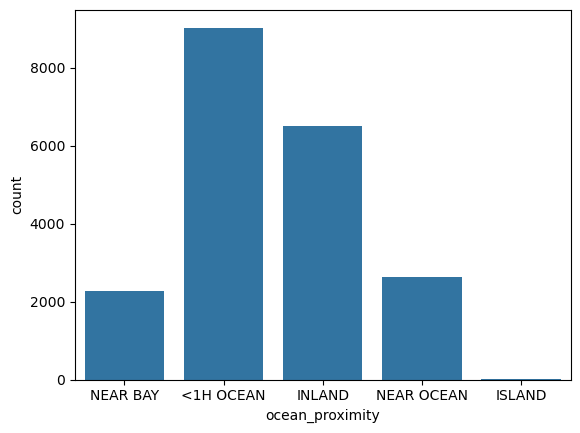

In [19]:
sns.countplot(x='ocean_proximity',data=df)

<Axes: xlabel='ocean_proximity'>

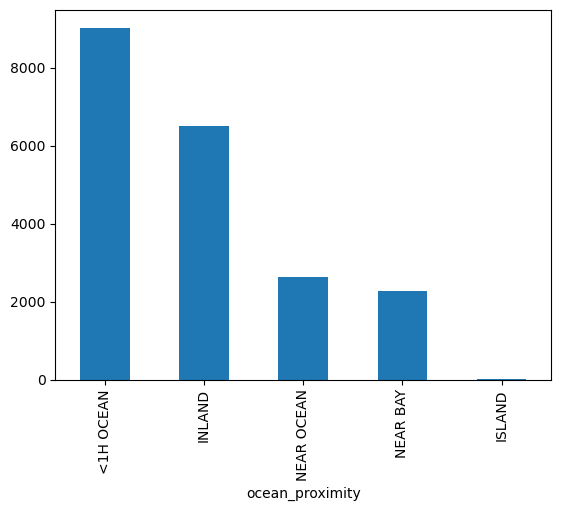

In [20]:
df['ocean_proximity'].value_counts().plot(kind='bar')

In [21]:
li=list(df.columns)

In [22]:
li

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value',
 'ocean_proximity']

In [24]:
li=li[:-1]

In [25]:
li

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value']

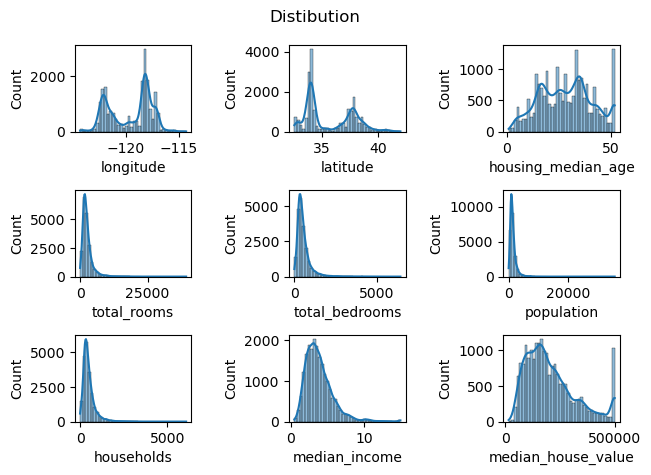

In [27]:
fig,axis=plt.subplots(nrows=3,ncols=3)
fig.suptitle("Distibution")
for i,col in enumerate(li):
    row=i//3
    coli=i%3
    ax=axis[row,coli]
    sns.histplot(data=df,x=col,kde=True,ax=ax,bins=40)
plt.tight_layout()
plt.show()


In [28]:
df.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924616,-0.109357,0.045480,0.069608,0.100270,0.056513,-0.015550,-0.045398
latitude,-0.924616,1.000000,0.011899,-0.036667,-0.066983,-0.108997,-0.071774,-0.079626,-0.144638
housing_median_age,-0.109357,0.011899,1.000000,-0.360628,-0.320451,-0.295787,-0.302768,-0.118278,0.106432
total_rooms,0.045480,-0.036667,-0.360628,1.000000,0.930380,0.857281,0.918992,0.197882,0.133294
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.100270,-0.108997,-0.295787,0.857281,0.877747,1.000000,0.907186,0.005087,-0.025300
households,0.056513,-0.071774,-0.302768,0.918992,0.979728,0.907186,1.000000,0.013434,0.064894
median_income,-0.015550,-0.079626,-0.118278,0.197882,-0.007723,0.005087,0.013434,1.000000,0.688355
median_house_value,-0.045398,-0.144638,0.106432,0.133294,0.049686,-0.025300,0.064894,0.688355,1.000000


<Axes: >

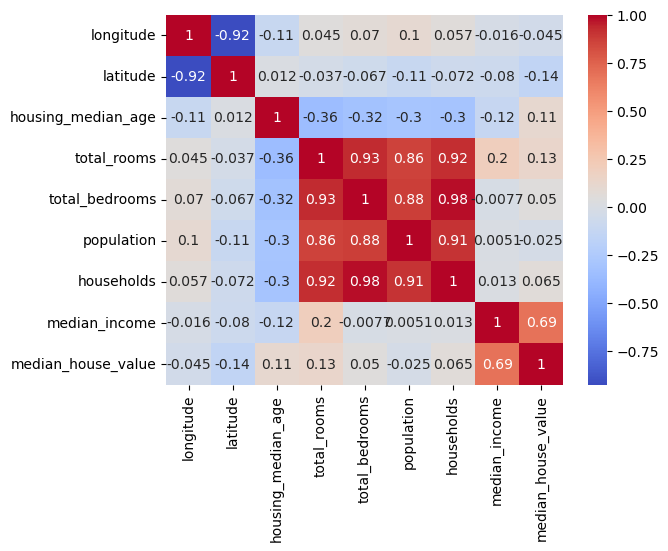

In [31]:
import seaborn as sns

corr = df.drop(['ocean_proximity'], axis=1).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

<Axes: xlabel='longitude', ylabel='median_house_value'>

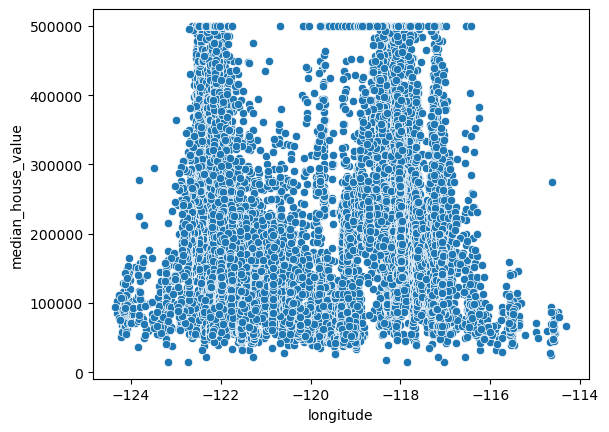

In [32]:
sns.scatterplot(x="longitude",y="median_house_value",data=df)

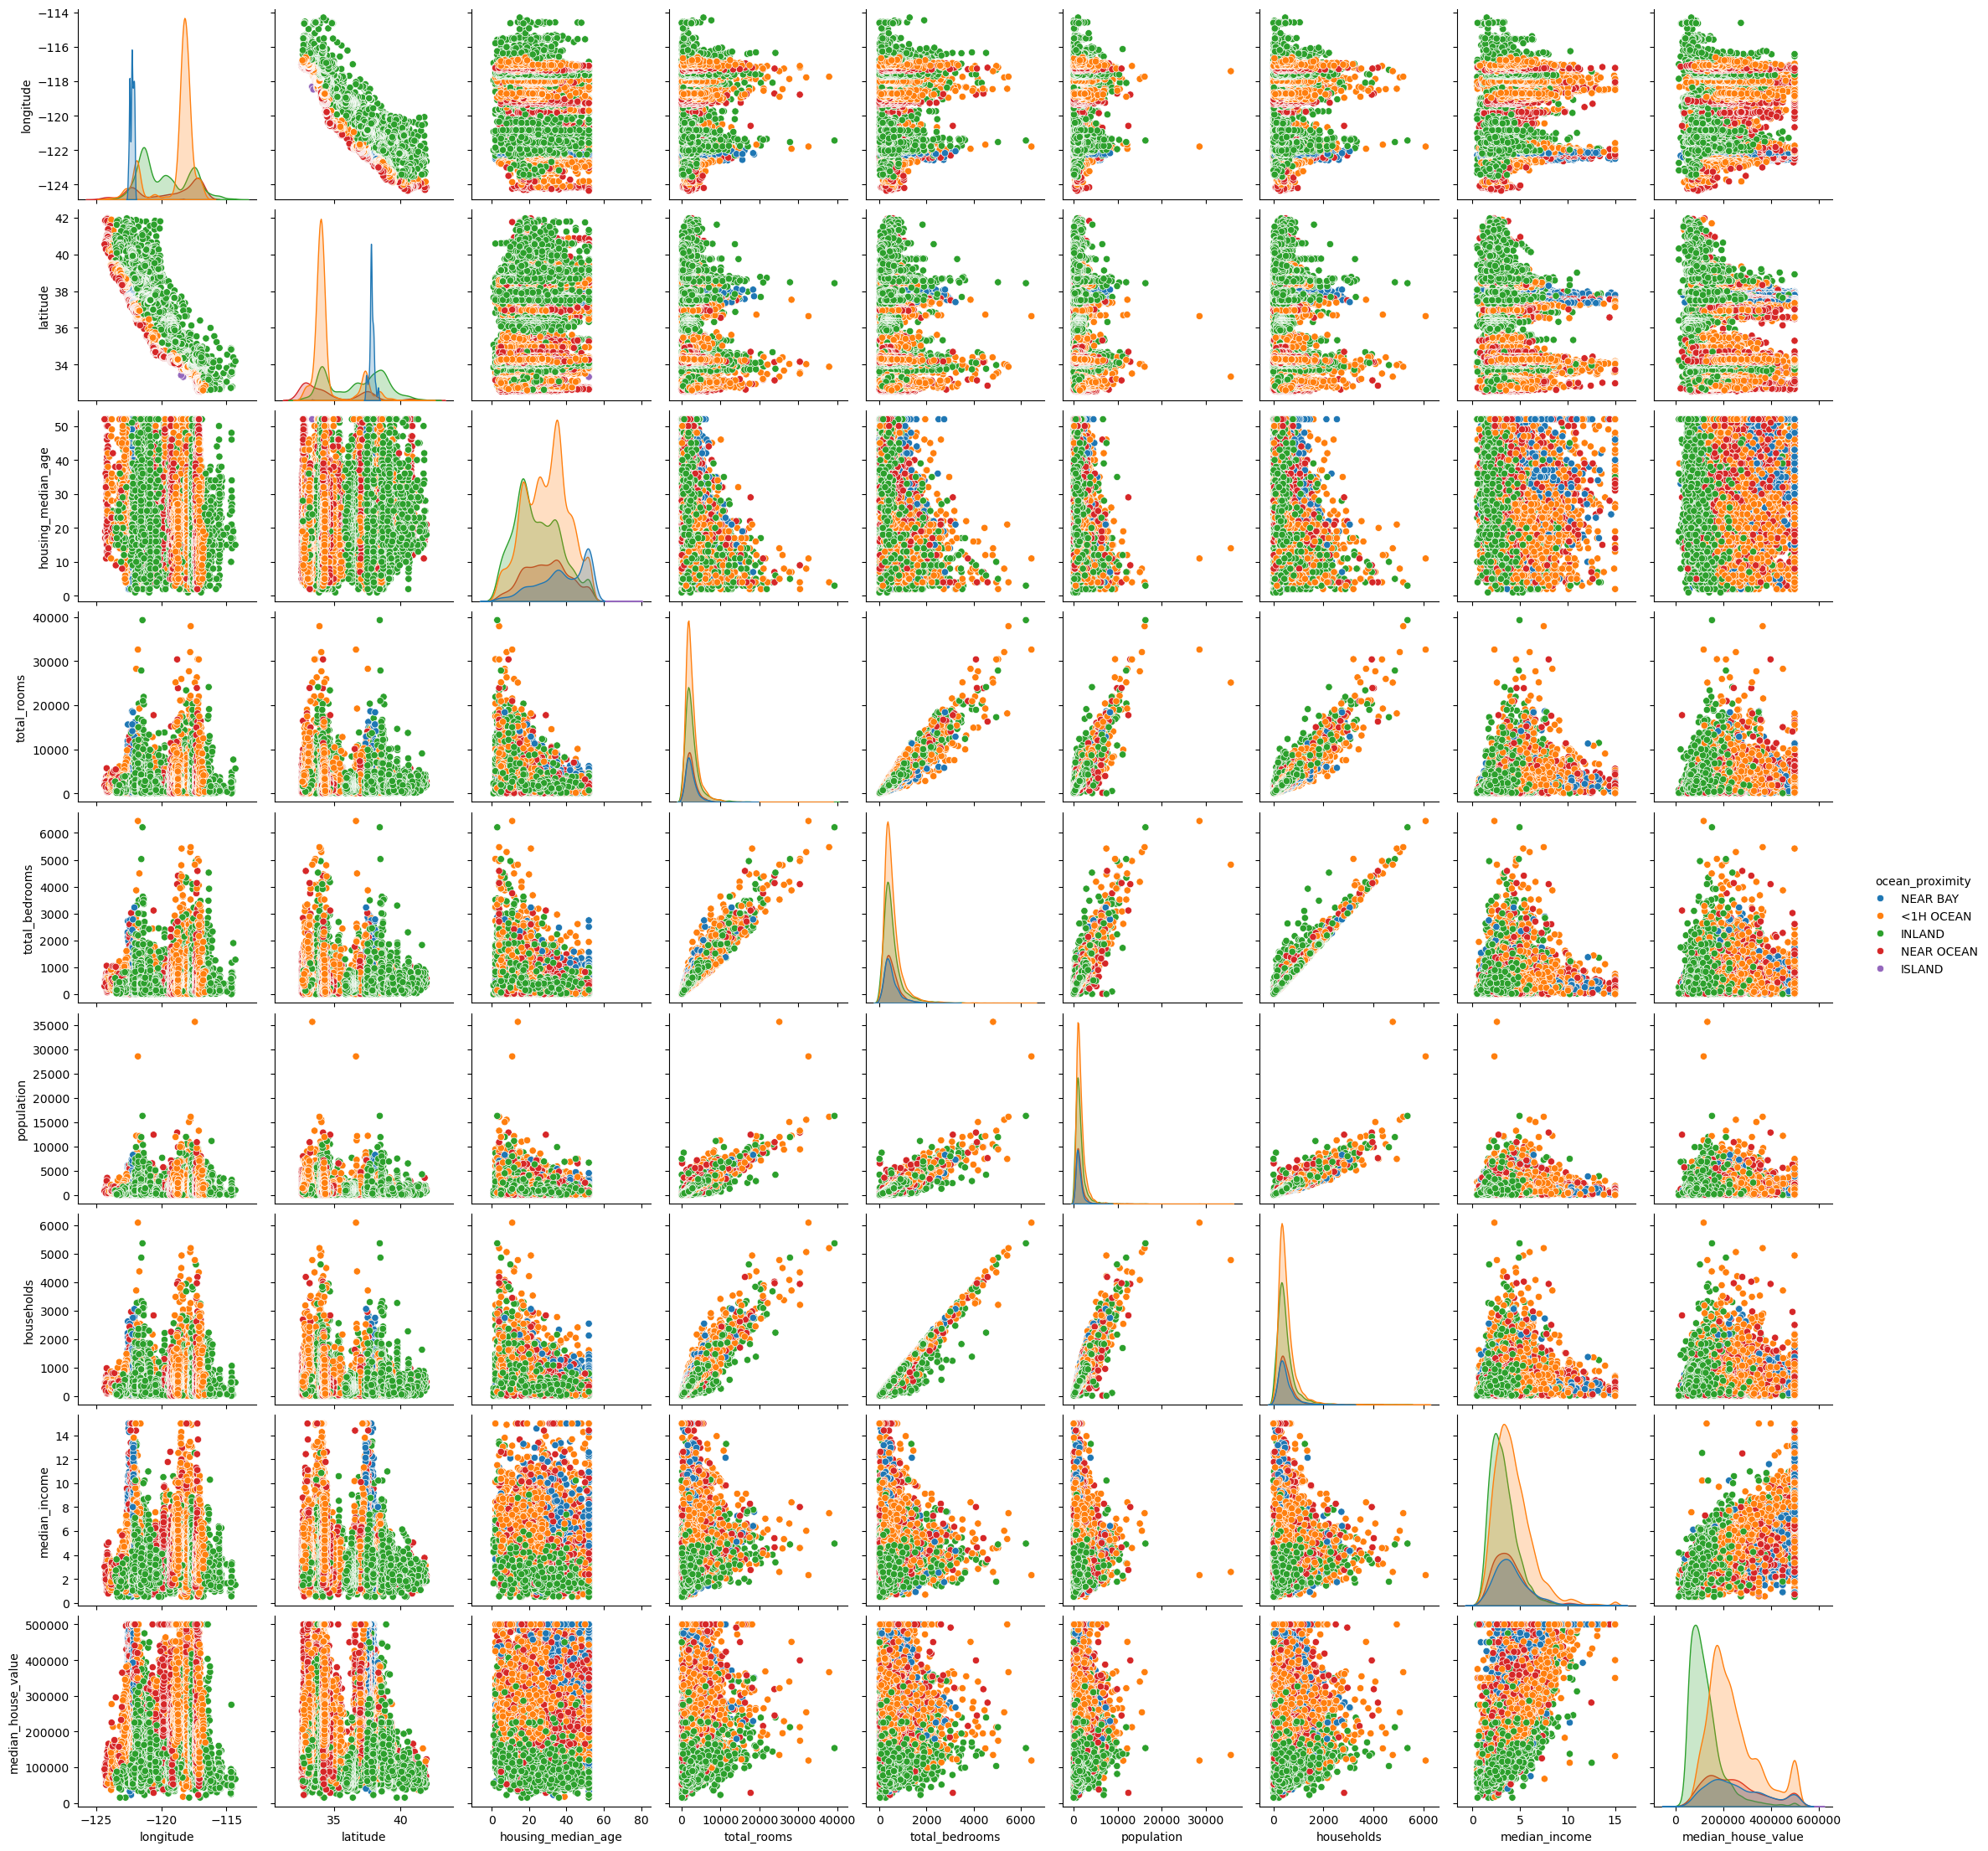

In [36]:
sns.pairplot(df,hue='ocean_proximity')

c:\Users\kanha\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


<Axes: >

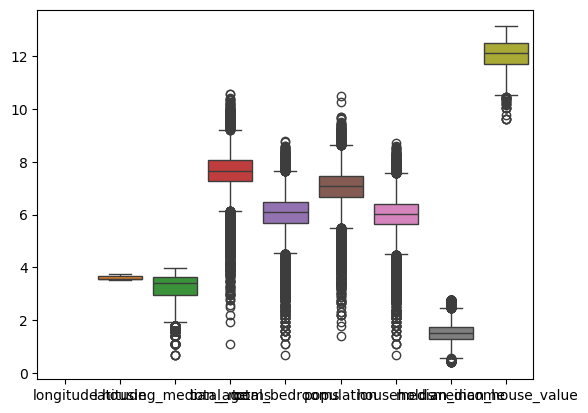

In [39]:
sns.boxplot(data=np.log1p(df[li]))

<Axes: xlabel='median_income', ylabel='median_house_value'>

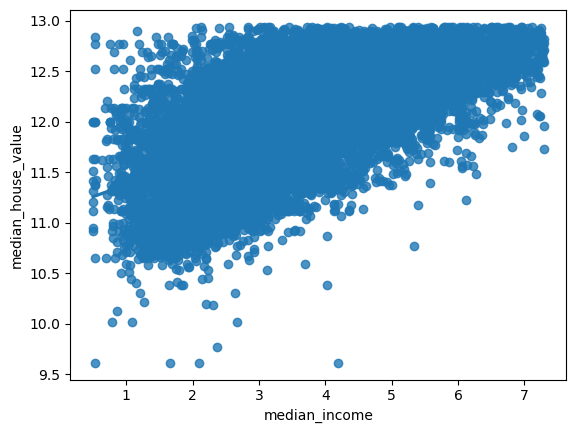

In [69]:
sns.regplot(x="median_income",y=np.log1p(df['median_house_value']),data=df)

<Axes: xlabel='ocean_proximity', ylabel='median_income'>

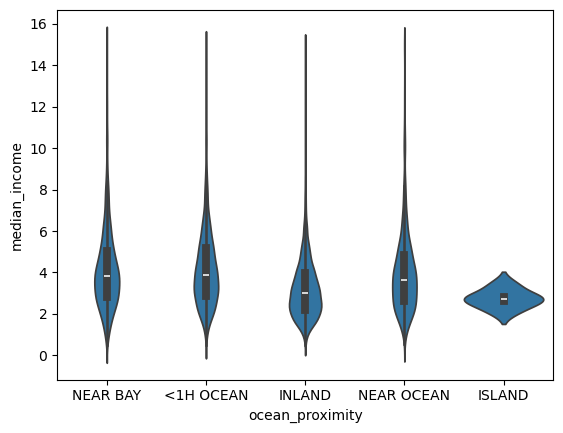

In [40]:
sns.violinplot(x='ocean_proximity', y='median_income', data=df)

In [47]:
for col in li:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower, upper)

c:\Users\kanha\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


<Axes: >

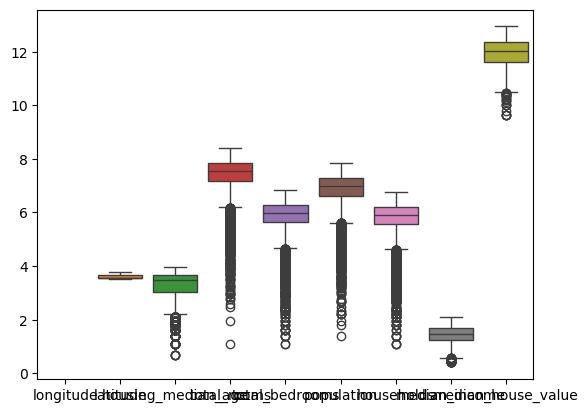

In [48]:
sns.boxplot(data=np.log1p(df[li]))

<Axes: xlabel='median_house_value'>

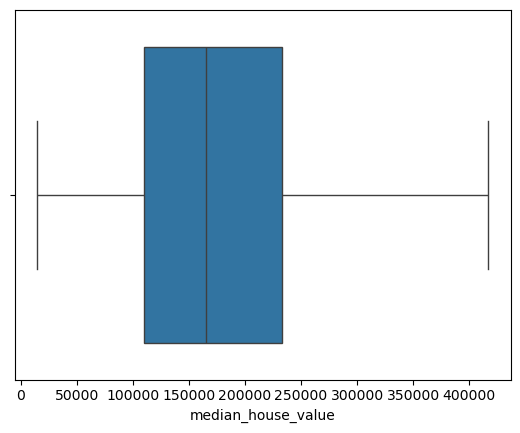

In [52]:
sns.boxplot(x=df['median_house_value'])

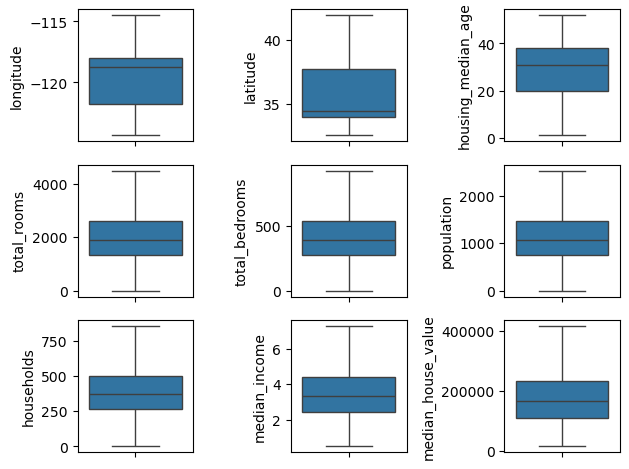

In [55]:
fig,axes=plt.subplots(nrows=3,ncols=3)
for i,col in enumerate(li):
    row=i//3
    ci=i%3
    ax=axes[row,ci]
    sns.boxplot(data=df[col],ax=ax)
plt.tight_layout()
plt.show()

<Axes: xlabel='longitude', ylabel='latitude'>

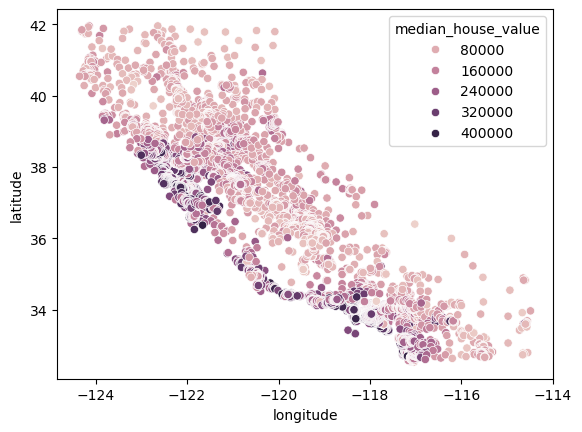

In [56]:
sns.scatterplot(x='longitude', y='latitude', hue='median_house_value', data=df)

In [57]:
df['rooms_per_household'] = df['total_rooms'] / df['households']

In [58]:
df['rooms_per_household'] = df['total_rooms'] / df['households']

<Axes: xlabel='total_rooms', ylabel='median_house_value'>

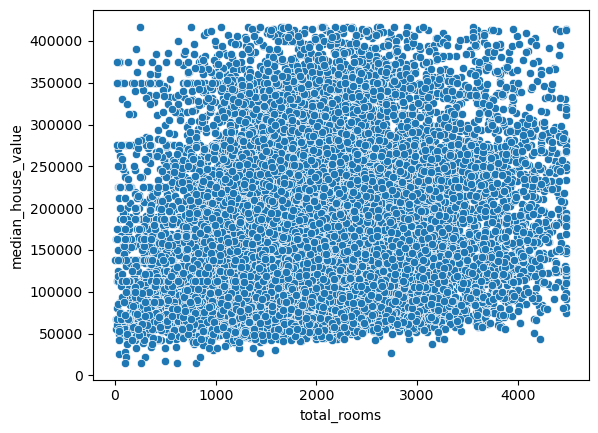

In [60]:
sns.scatterplot(x='total_rooms', y='median_house_value', data=df)

<Axes: xlabel='median_income', ylabel='Density'>

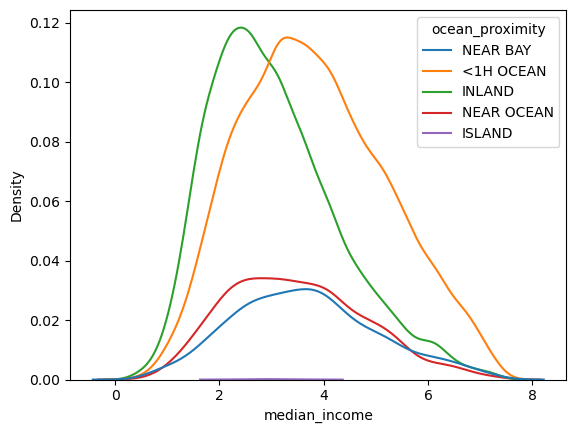

In [61]:
sns.kdeplot(data=df, x='median_income', hue='ocean_proximity')

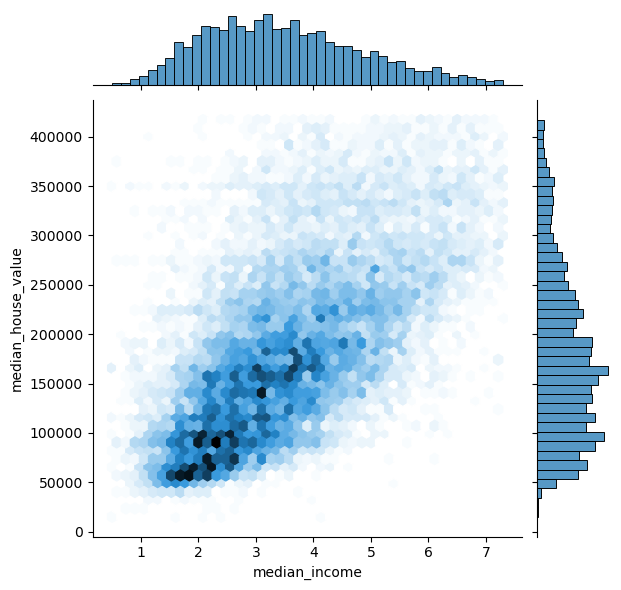

In [62]:
sns.jointplot(x='median_income', y='median_house_value', data=df, kind='hex')

<Axes: xlabel='housing_median_age', ylabel='median_house_value'>

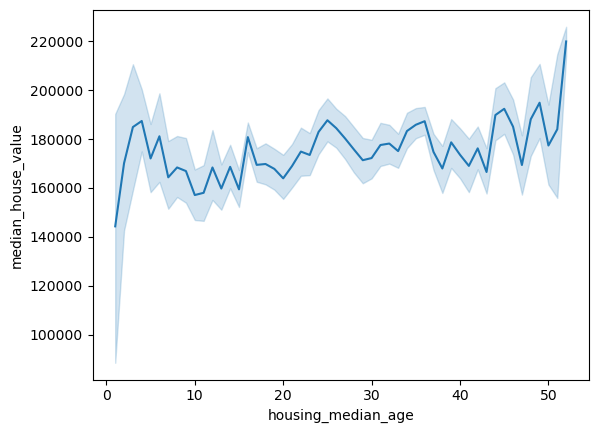

In [63]:
sns.lineplot(x='housing_median_age', y='median_house_value', data=df)

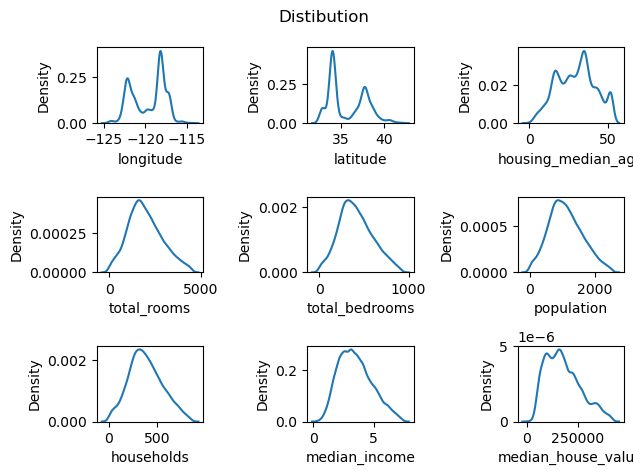

In [ ]:
fig,axis=plt.subplots(nrows=3,ncols=3)
fig.suptitle("Distibution")
for i,col in enumerate(li):
    row=i//3
    coli=i%3
    ax=axis[row,coli]
    sns.kdeplot(data=df,x=col,ax=ax)
plt.tight_layout()
plt.show()

In [67]:
new_cols=list(df.columns)

In [68]:
new_cols

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value',
 'ocean_proximity',
 'rooms_per_household']

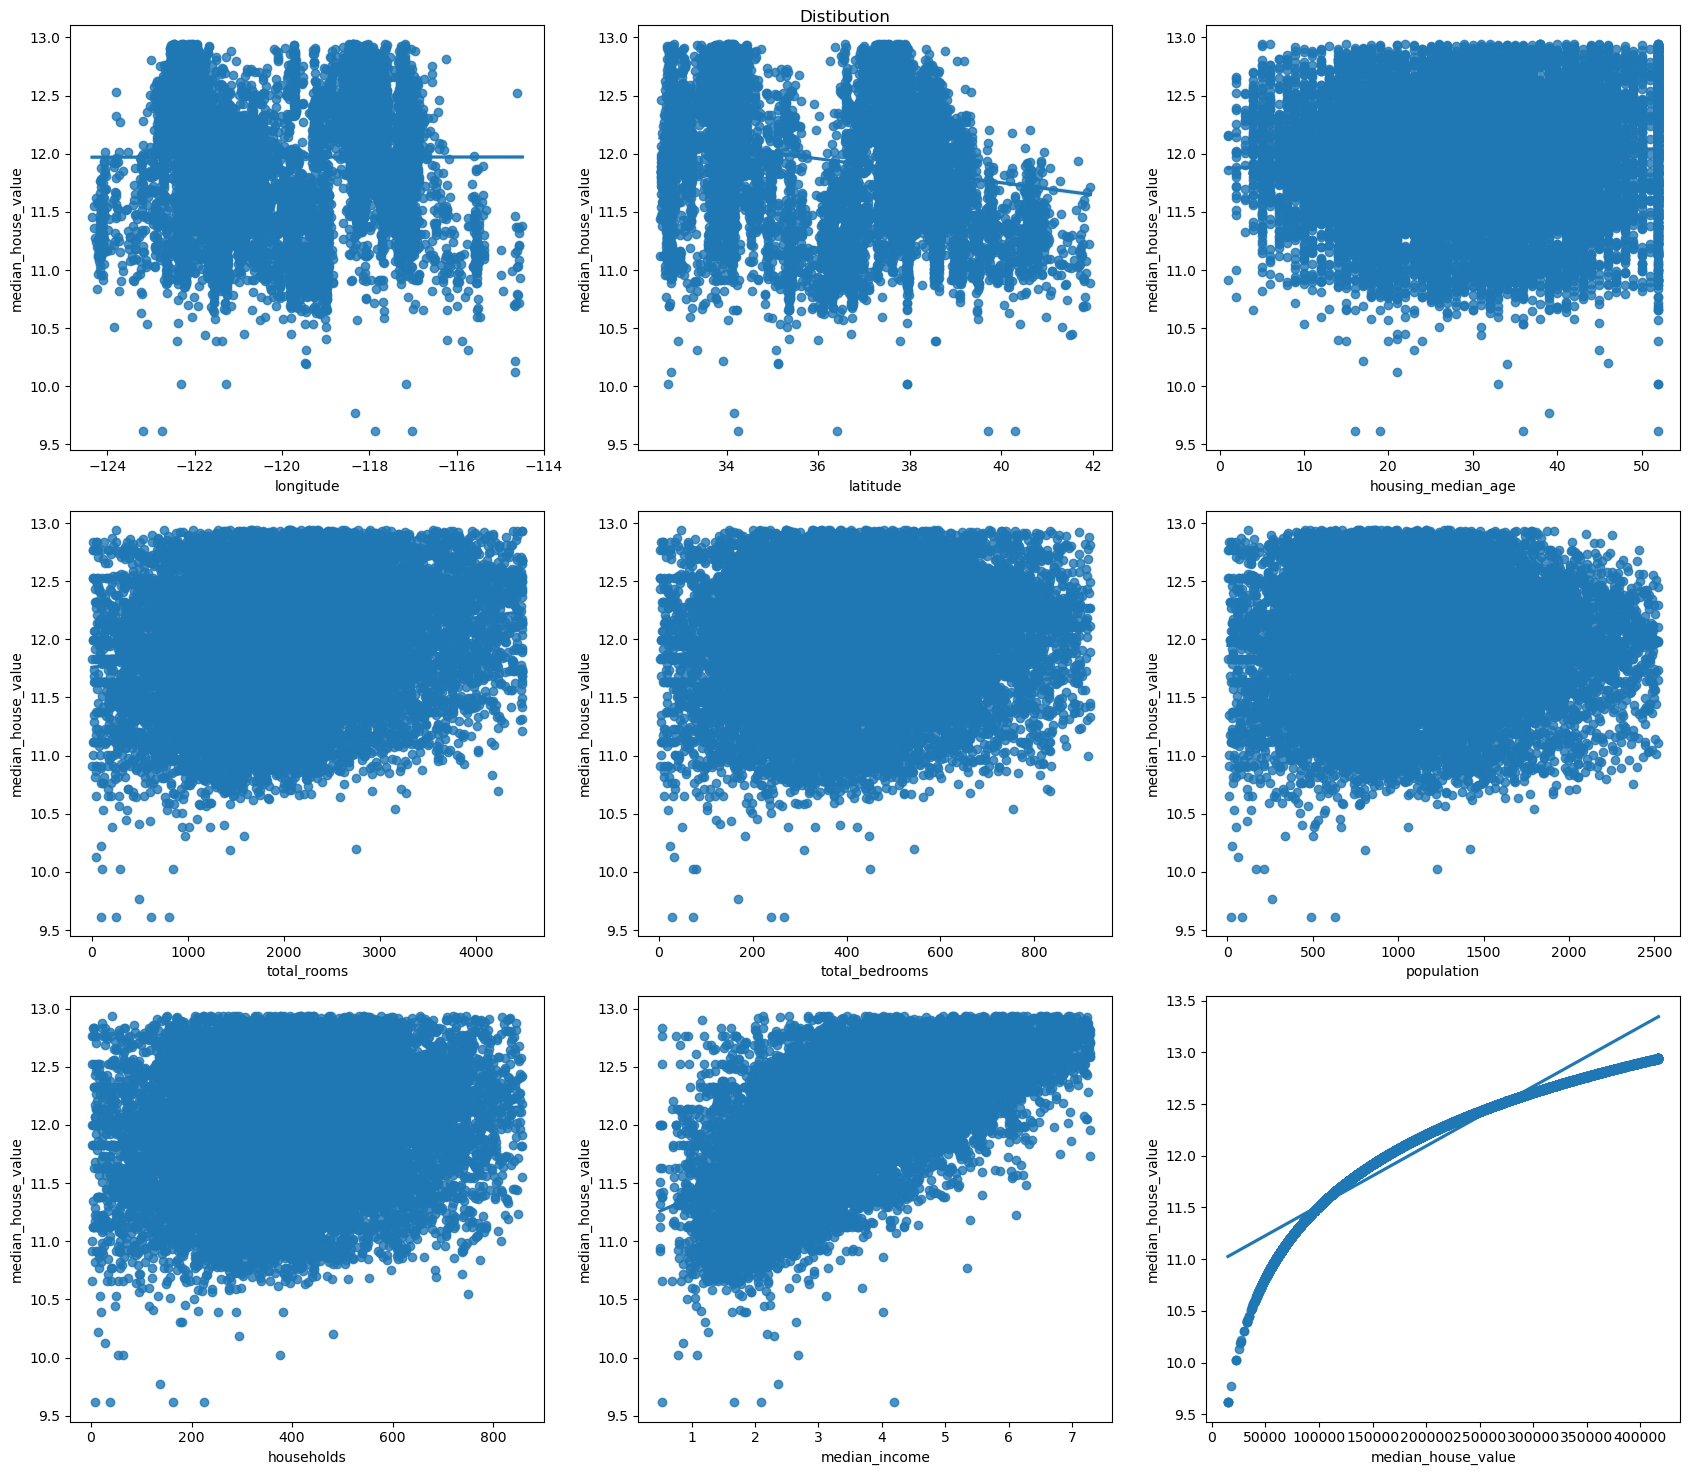

In [73]:
fig,axis=plt.subplots(nrows=3,ncols=3,figsize=(17,15))
fig.suptitle("Distibution")
for i,col in enumerate(li):
    row=i//3
    coli=i%3
    ax=axis[row,coli]
    sns.regplot(data=df,x=col,y=np.log1p(df["median_house_value"]),ax=ax)
plt.tight_layout()
plt.show()